# 信用卡欺诈检测特征工程汇报版

**整理范围：** `credit-fraud-feature-engineering.ipynb`、`credit-fraud-feature-engineering-1.ipynb` 到 `credit-fraud-feature-engineering-6.ipynb`。  
**生成时间：** 2026-06-26 13:41  
**用途：** 汇报展示，保留关键图表和运行结果；省略重复代码和重复全量表。


## 1. 最终结论

最终选定的特征组是：

**`IF + hours_since_start + log1p_amount + A_top2`**

也就是在 BASE 特征 `V1–V28 + Amount + Time` 之外，新增：

| 类型 | 特征 |
| --- | --- |
| BASE | V1–V28, Amount, Time |
| 最终新增 | if_oof_score |
| 最终新增 | hours_since_start |
| 最终新增 | log1p_amount |
| 最终新增 | one_euro_V14, one_euro_V4 |

后续训练结果：

| 路线 | best_model | AUC-PR | F1 | Precision | Recall | FP | FN |
| --- | --- | --- | --- | --- | --- | --- | --- |
| StratifiedKFold 最终训练 | LightGBM | 0.8628 | 0.8742 | 0.9372 | 0.8191 | 27 | 89 |
| purgedcv 最终训练 | XGBoost | 0.7982 | 0.6717 | 0.8812 | 0.5427 | 36 | 225 |



## 2. 从业务假设到特征：探索性数据分析

按行业背景提出假设，再用数据和图表验证强弱，最后决定是否产出候选特征。

这些结论只是候选池来源，不是最终定稿；最终是否保留要看后续 FE1–FE6 的交叉验证。


### 2.1 欺诈金额分布不同——Amount 分布验证
假设：欺诈样本的金额分布不同于正常样本。

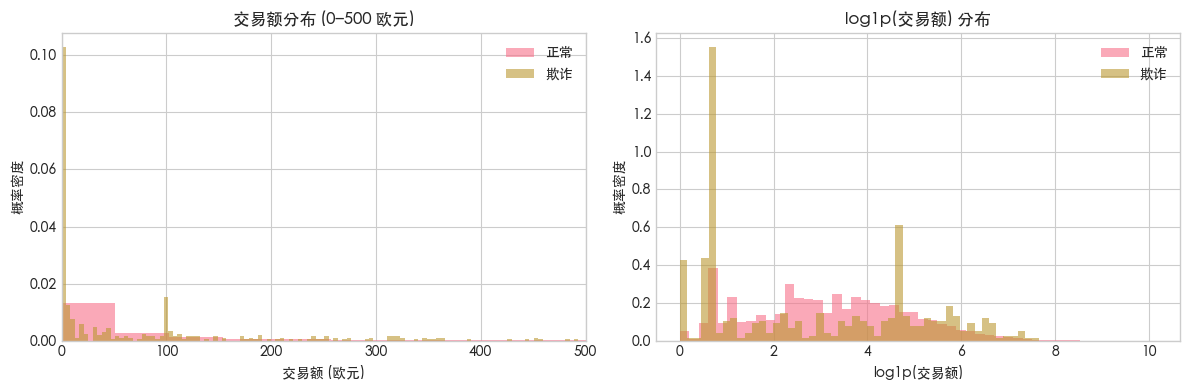

欺诈与正常交易的 Amount 分布不同，图中观察到长尾效应显著，尝试 `log1p_amount` （对Amount列取对数）特征。

### 2.2 小额卡测试——小额欺诈发生率高于均值验证

假设：欺诈更容易集中在小额卡测试交易。

验证结果：

| 证据 | 数值 |
| --- | --- |
| `Amount == 1.0` 欺诈笔数 | 113 笔 |
| `Amount == 1.0` 占全部欺诈比例 | 23.0% |
| `Amount == 1.0` 处欺诈率提升 | 4.81 |
| `Amount < 1` 欺诈占比 | 13.82% |
| `Amount < 1` 正常占比 | 5.89% |
| `Amount < 1` 欺诈/正常倍数 | 2.35 |

结论：小额卡测试假设成立，但不要做“危险度分数”这种人为打分指标，可能引入过多噪声；更稳妥的是保留事实特征，让树模型自己学习切分。

产生候选特征：`is_micro_testing`（<1欧）、`is_small_testing`（>1且<=5欧）、`is_one_euro`（=1欧）。  
后续取舍中：`is_one_euro` 更适合作为特征交叉的门控（大量误报产生在1欧处），`is_small_testing` 后来因效果不好被难样本金额带替代（该区间欺诈发生率本就低于均值）。

### 2.3 深夜/非活跃时段欺诈率更高——欺诈的时间聚集 / 非活跃时段发生率验证

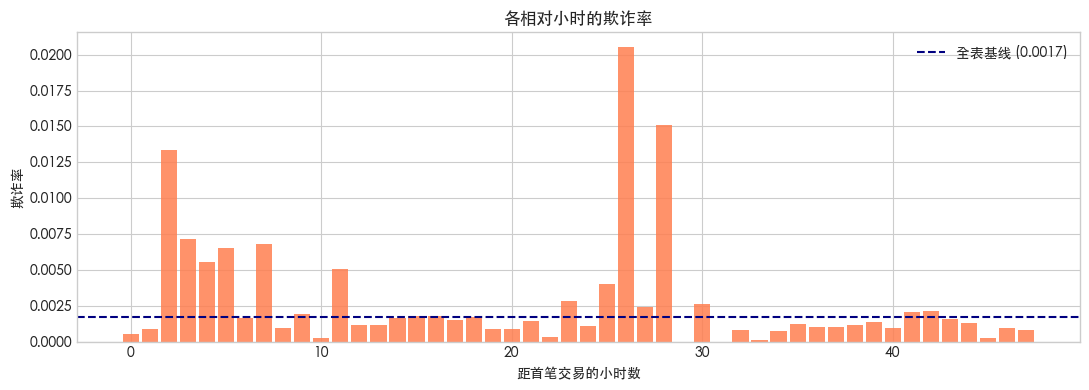

假设：欺诈在时间上存在聚集，低流量时段可能更危险。由于 `Time` 是距首笔交易的秒数，不是自然时钟，因此这里用相对小时 `hours_since_start = Time // 3600`。

验证结果：最高风险小时桶欺诈率约为全局基线的 11.89 倍；按交易量划分的非活跃小时欺诈率为 0.0026，活跃小时为 0.0014，约 1.89 倍。

结论：时间聚集假设部分成立。产生候选特征 `hours_since_start` 和 `is_inactive`；后续保留 `hours_since_start`，`is_inactive` 过粗且在 FE1 中不稳定，丢弃。

### 2.4 批量盗刷或卡测试——短交易间隔验证

假设：批量盗刷或卡测试可能表现为短时间内连续交易，因此相邻交易间隔越短，欺诈率可能越高。

验证限制：数据集没有 `card_id` / `account_id`/ `recipient_id`，只能按全局 `Time` 排序计算与上一笔交易的间隔。这个间隔混合了多张卡，因此只能作为弱参考。

验证结果：

| 指标 | 正常 | 欺诈 |
| --- | --- | --- |
| `time_diff` 中位数 | 1.0 秒 | 1.0 秒 |
| `time_diff` 均值 | 1.4 秒 | 2.2 秒 |
| `time_diff` 75% 分位 | 1.0 秒 | 2.0 秒 |

短间隔窗口欺诈率也没有形成强支持：`≤1s` 欺诈率为 0.0014，低于全局基线约 0.0017；`≤5s` 为 0.0018，`≤10s` 为 0.0019，提升很弱。

结论：短交易间隔假设不成立 / 无法可靠验证。不产出特征，避免把全局流水间隔误当成同卡行为。

### 2.5 套现——异常大额交易验证

假设：异常大额交易可能更容易是欺诈。

验证方法：用全表 `Amount` 的 z-score 做 EDA 粗看，比较高 z-score 子集的欺诈率和全局基线。这里仅用于探索；如果正式建模使用 scaler，需要在训练折内 fit，避免泄露。

验证结果：

| 条件 | 样本数 | 欺诈率 | 全局基线 |
| --- | ---: | ---: | ---: |
| `amount_z > 1` | 15,710 | 0.0033 | 0.0017 |
| `amount_z > 2` | 7,319 | 0.0040 | 0.0017 |
| `amount_z > 3` | 4,076 | 0.0027 | 0.0017 |

结论：异常大额只有弱支持，没有形成清晰分界，也不值得单独造一个 z-score 桶。最终用 `log1p_amount` 表达金额长尾尺度，把具体切分交给模型。

## 3. 基线模型与难样本

基线模型只使用最基础特征：`V1–V28 + Amount + Time`，不加入衍生特征。这个基线用于回答：模型在没有额外特征时表现怎样，错在哪里。

随机种子42偏乐观：  
| 模型 | 特征 | AUC-PR | F1@0.5 | Precision@0.5 | Recall@0.5 |
| --- | --- | --- | --- | --- | --- |
| LightGBM | V1–V28 + Amount + Time | 0.8767 | 0.8469 | 0.8469 | 0.8469 |
| XGBoost | V1–V28 + Amount + Time | 0.8756 | 0.8586 | 0.8817 | 0.8367 |

选 LightGBM 做难样本分析，因为它在验证集 AUC-PR 略高。其 @0.5 混淆矩阵为 `[[56849, 15], [15, 83]]`，即 FP=15、FN=15。阈值附近不确定带宽度（|p - threshold| < UNCERTAIN_BAND = 0.15 → hard_uncertain）


| 组别 | 样本数 | Amount中位数 | 含义 |
| --- | --- | --- | --- |
| hard_FP | 15 | 1.00 | 正常交易被判成欺诈，主要集中在 1 欧（正常交易被判为卡测试）。 |
| hard_FN | 15 | 3.79 | 欺诈交易被漏掉，金额更接近正常分布（>1且<=100的欺诈非高发带）且 PCA 边界模糊。 |
| hard_uncertain | 3 | 1.00 | 判断正确但概率接近阈值的样本，作为辅助观察。 |

从这里产生两个后续方向：

- **1 EUR 门控**：用 `is_one_euro` 衍生特征和V特征做交叉，因为 hard_FP 明显集中在 1 EUR，小额正常交易容易被误报。
- **难样本金额带**：从 hard sample 的金额画像扩展出 `is_amount_1_30`（1<amount<=30）、`is_amount_75_110`(75<=amount<=110)，用于替代早期太粗的 `is_small_testing`。


### 难样本金额画像

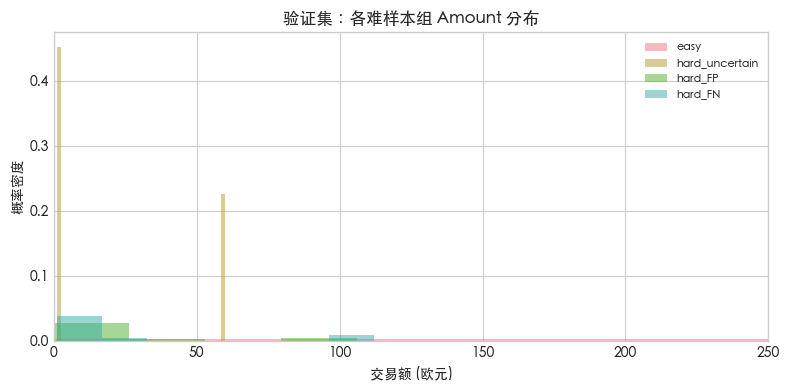

hard_FP、hard_FN、hard_uncertain，实际样本打印出来后，多集中在难样本金额带和已有的衍生特征（如`is_micro_testing`、`is_one_euro`）上。  
另外观察到还有一个误判区间，即 1<amount<5 欧。但实际将 `is_small_testing` 改成这个范围并进行特征消融测试后，效果不理想。

## 4. 欺诈的 PCA / KMeans 画像：欺诈是否存在明显的模式？

对欺诈样本做 KMeans 肘部图和 PCA 画像，结论是：

- KMeans 找不到清晰肘部，说明欺诈模式没有明显边界，可能是连续分布或许多重叠小模式。
- PCA 画像中，欺诈样本内部各类型点重叠，边界模糊；正常和欺诈样本也重叠严重。
- 每簇看不出明显业务逻辑或数据价值，因此 **分簇子模型或许没有太大用**。

后续转向“事实特征 + 基于难样本的门控交叉特征 + 孤立森林 OOF 异常分”。


### KMeans 肘部图

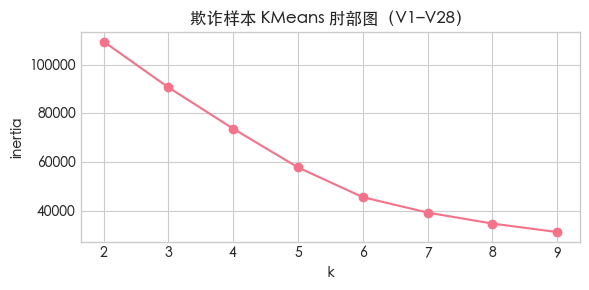

肘部不明显：没有清楚的 K 值可选。

### 欺诈样本 PCA 画像

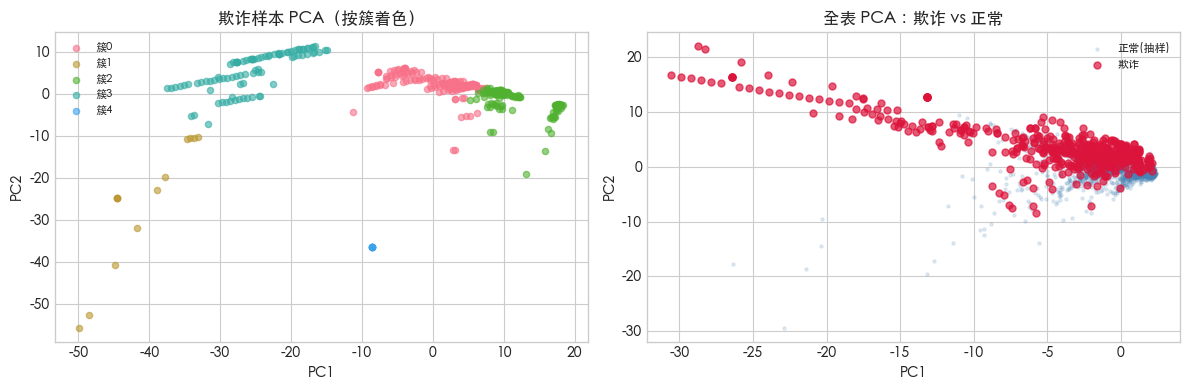

欺诈内部不同簇重叠明显，难以解释成稳定业务分群。

### 正常 vs 欺诈 PCA 画像

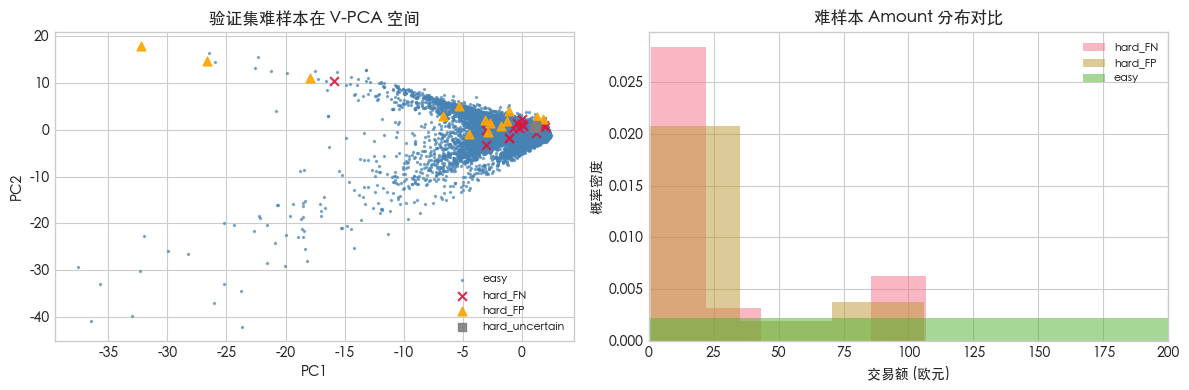

正常与欺诈在二维 PCA 投影上重叠严重，分簇子模型收益可能有限。

## 5. 候选特征簇说明

| 候选簇 | 特征 | 含义 |
| --- | --- | --- |
| BASE | V1–V28, Amount, Time | Kaggle 原始匿名 PCA 变量 + 原始金额/时间；所有实验的共同底座。 |
| EDA 事实特征 | log1p_amount | 金额分布显著不同，用 log 缩放保留金额尺度，对抗长尾效应。 |
| EDA 事实特征 | hours_since_start | 相对首笔交易的小时数；时间桶欺诈率存在聚集。 |
| EDA 事实特征 | is_micro_testing | Amount < 1，超小额卡测试信号。 |
| EDA 事实特征 | is_small_testing | 早期定义为 1 < Amount <= 20；后续发现效果不稳定，改为1 < Amount <= 5，仍不行。 |
| EDA 事实特征 | is_one_euro | Amount == 1.0；最终没有直接入选，但作为特征交叉的基石。 |
| EDA 事实特征 | is_inactive | 低交易量小时桶；过粗且不稳定，未进最终。 |
| 难样本金额带 | is_amount_1_30 | 从 hard sample 观察扩展出的中小额难样本带；表现不错，但 seed 稳定性不足。 |
| 难样本金额带 | is_amount_75_110 | 从 hard sample/金额画像扩展出的中额难样本带；表现不错，但 seed 稳定性不足。 |
| Family A 交叉特征 | one_euro_V14, one_euro_V4, ... | `is_one_euro × Top-V`。不是简单标记 1 EUR，而是在 1 EUR 子空间内让一些高增益的 V 特征发挥作用；最终 A_top2=V14, V4。 |
| OOF Autoencoder | ae_oof_error | 使用 AutoEncoder 训练误差异常分；FE2/FE4/FE5 显示其结果不稳定，最终不用。 |
| OOF Isolation Forest | if_oof_score | 使用孤立森林训练误差异常分。每折只用训练折正常样本拟合 IF，再给验证折打分，防止泄露；效果明显，最终保留。 |


## 6. FE1–FE3：StratifiedKFold 路线

这条路线的目的不是防时间泄露（反正原始特征经过 PCA 脱敏处理后，由于欺诈行为的时间自相关性，已经发生了时间上的泄露），而是在较稳定的分层 CV 下快速筛特征族。

| 版本 | 验证方式 | 异常分 | 核心结论 | 后续动作 |
| --- | --- | --- | --- | --- |
| FE-1 | StratifiedKFold | OOF Autoencoder | 原始 EDA 事实特征不是全部有用；`is_small_testing` / `is_inactive` 等不稳定，不能整包加入。 | 改造 EDA 特征，把注意力转向难样本产生的金额带。 |
| FE-2 | StratifiedKFold | OOF Autoencoder | AE 单列或 AE 组合没有稳定业务价值，容易成为噪声。 | 把 AE 换成 Isolation Forest。 |
| FE-3 | StratifiedKFold | OOF Isolation Forest | StratifiedKFold 路线定稿为 `IF + hours_since_start + log1p_amount + A_top2`。 | 进入时间序列验证，检查是否存在时间泄露。 |

StratifiedKFold 后续模型训练中，`IF + hours_since_start + log1p_amount + A_top2` 的最终结果如下：

| 模型 | AUC-PR_mean | AUC-PR_std | F1@best | Precision | Recall | FP | FN |
| --- | --- | --- | --- | --- | --- | --- | --- |
| LightGBM | 0.8628 | 0.0215 | 0.8678 | 0.9126 | 0.8272 | 39 | 85 |
| XGBoost | 0.8626 | 0.0245 | 0.8660 | 0.9161 | 0.8211 | 37 | 88 |

对比基线模型：
| 模型 | CV_AUC-PR_mean | CV_AUC-PR_std |
| --- | --- | --- |
| LightGBM | 0.8578 | 0.0217 |
| XGBoost | 0.8578 | 0.0273 |  

折腾一堆但提升不大🤔


## 7. FE4–FE6：时间序列验证 / 防泄露路线

这条路线和 FE1–FE3 是不同思路：核心目标是降低时间泄露风险。

| 版本 | 验证方式 | 异常分 | 核心结论 | 后续动作 |
| --- | --- | --- | --- | --- |
| FE-4 | TimeSeriesSplit | OOF Autoencoder | 尝试按时间顺序验证以降低泄露风险；该版本主要是验证方式探索，没有形成最终特征结论。 | 换更严格、更贴近业务切分的 purgedcv。 |
| FE-5 | purgedcv WalkForwardSplit | OOF Autoencoder | purgedcv 比普通 TSS 更严格：walk-forward + embargo，更适合时间序列欺诈任务。 | 保留 purgedcv 框架，把 AE 替换为 IF。 |
| FE-6 | purgedcv WalkForwardSplit | OOF Isolation Forest | 主矩阵中 `Ed_bands+IF+A_top2` seed=42 好，但 seed=123 的 表现不稳；补测后最终选 `IF + hours + log1p + A_top2`。 | 将该组进入后续模型训练/调参。 |


### 最终特征组合在两种验证思路下的结果差异

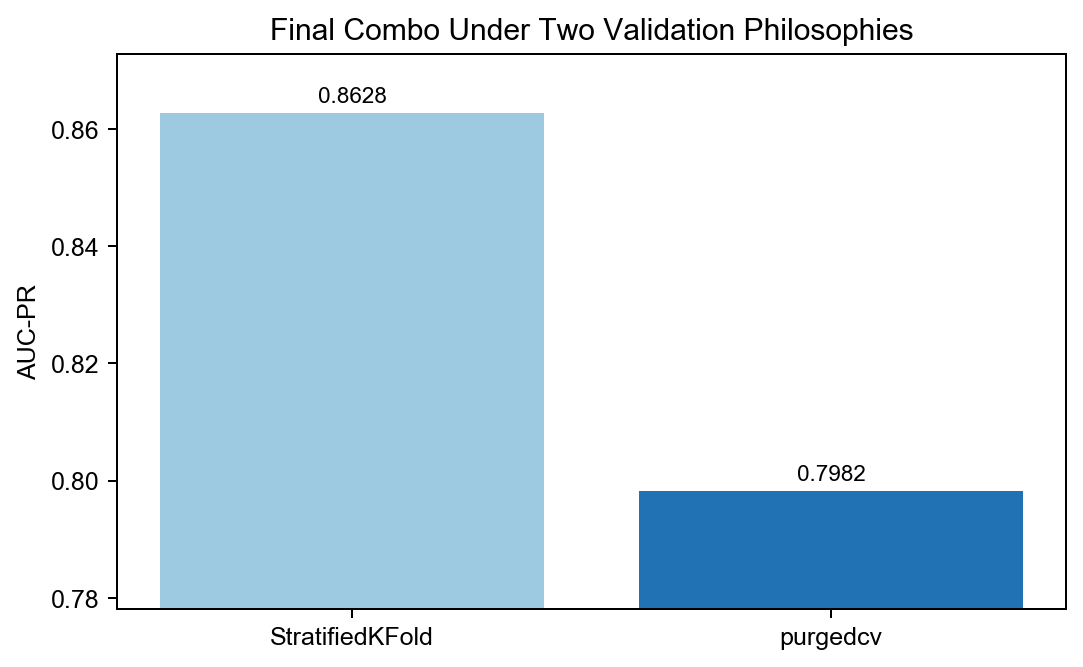


## 8. 模型对正负样本的判断集中在某个阈值附近怎么办  

如果一个模型对正负样本的判断集中在某阈值附近，那么这个模型哪怕 AUC-PR 和 F1_score 得分高，实际也很难用，因为他给出的判断太不确定了。

解决办法：  
1. 尝试对 hard_uncertain 做特征工程，增加一个新特征（已做✅）。  
2. 通过模型在训练中OOF预测，选个区间定义落到其中的为模糊样本，增加这些样本的权重（使用树模型的sample_weight参数）。使用网格搜索确定最优权重（待尝试）。

## 9. 如何权衡AUC-PR和F1_score  

AUC-PR：在所有可能阈值下，正样本是否整体排在负样本前面（排序/区分能力）  
F1@最优阈值：在某一个阈值上的 Precision 与 Recall 平衡  

高 AUC-PR 但 F1 一般，常见原因：  

1. PR 曲线形状：AUC-PR 高可能来自「容易样本排得很好」，但 概率（hard_uncertain）大量挤在 0.5 附近，任意阈值都难以同时拉高 Percision 和 Recall, F1上限低。
2. 类别不平衡：AUC-PR 对正类排序敏感；F1 受所选阈值影响。

解决办法：
1. 可通过前一单元中提到的办法解决。
2. 对于每次训练结果都使用 sklearn.metrics.precision_recall_curve 搜索最优F1。  

基于业务背景的评估流程：
1. 固定打扰率下的召回率（Recall @ Fixed FPR）  
银行的风控策略通常是：“我们最多只能容忍打扰 0.1% 的正常交易，在这个前提下，能抓出多少欺诈？”  
•	考核指标： FPR = 0.001  
•	实际操作： 本模型在特征工程时综合考量 AUC-PR 和 F1_score，**多目标优化**。虽仍以 AUC-PR 的稳定提升为主，但同时要求 F1_score 的稳定提升。即直接抛弃某一指标拉胯的模型，保留 AUC 和 F1 双优的模型人工选择。**对特征工程最后选出特征组的 FPR 进行计算，结果约为 0.00015，已自动满足业务需求，同时为模型上限保留了更大余地**
2. 资金挽回率（Dollar-Weighted Metrics）  
金额是风控的核心。  
•	考核指标： 金额召回率 (Value Recall) 和 金额误杀率 (Value Precision)  
•	实际操作： 不是考量抓对了几个“欺诈”，而是算追回了多少“钱”。一个抓住了 10 笔小额盗刷但漏掉 1 笔大额盗刷的模型（样本 F1 可能很高），在银行看来，远不如一个只抓住 1 笔大额盗刷但漏掉 10 笔小额盗刷的模型（样本 F1 较低，但挽回金额多）。**可能涉及对 Amount 的预测，并重新设计损失函数。暂不做，留待后续实现**

## 10. 最终组合：`IF + hours + log1p + A_top2`

`if_oof_score + hours_since_start + log1p_amount + one_euro_V14 + one_euro_V4`。

| seed | 模型 | AUC-PR_mean | Δ_AUC | F1@best | FP | FN |
| --- | --- | --- | --- | --- | --- | --- |
| 42 | LightGBM | 0.7840 | 0.0027 | 0.6541 | 45 | 231 |
| 42 | XGBoost | 0.7817 | 0.0030 | 0.6683 | 36 | 227 |
| 123 | LightGBM | 0.7907 | 0.0104 | 0.6658 | 27 | 233 |
| 123 | XGBoost | 0.7827 | 0.0043 | 0.6709 | 31 | 228 |


### 最终组合多 seed 结果

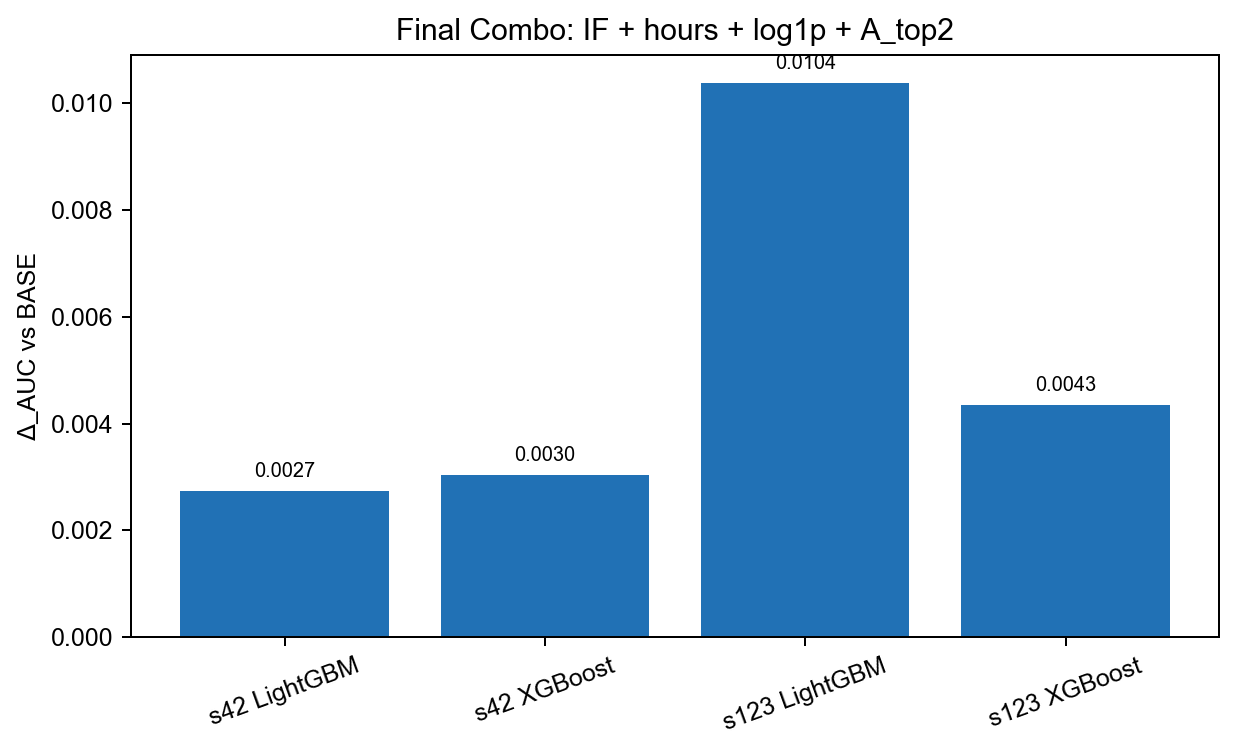

该组合虽然也有 seed 波动，但综合比较稳，F1@best 不错，且可解释性强。后续模型训练/调参阶段选择了它作为最终特征组。

## 11. 调参  

初步规划

Stage 1：学习率（learning_rate） × 类别权重（weight_scheme）。先决定整体学习速度和不平衡样本权重策略  
Stage 2：树结构复杂度。LightGBM：max_depth, num_leaves；XGBoost：max_depth。控制树的表达能力。  
Stage 3：叶子/子节点最小样本约束。LightGBM：min_child_samples；XGBoost：min_child_weight。控制过拟合，限制过细分裂。  
Stage 4：采样比例。subsample, colsample_bytree。控制行采样和列采样。  
Stage 5：正则化。reg_alpha, reg_lambda。调 L1 / L2 正则。